# Credit-Card Customer Segmentation
### Finding natural customer groups in six months of card behaviour, so each group can be offered the right product

**The business question.** We have 8,950 active credit-card customers and 17 numbers describing how each one used their card over the last six months: how much they carry as a balance, how much they buy, whether they buy in one go or in installments, whether they take cash advances, and how they repay. Marketing wants a small number of customer groups ("segments") so that saving plans, loans, wealth-management offers and risk-management actions can be targeted at the right people.

**How to read this notebook.** Every block of code is preceded by a short explanation in plain language: what the step does, why it is there, and what the result told us. Where a technical reader may want more detail, a *Technical note* follows in a grey box; it can be skipped without losing the thread.

**The route we take, in eight phases**

| Phase | What happens | Why |
|---|---|---|
| 1 | Load, audit and clean the data | Bad inputs produce bad segments |
| 2 | Build behaviour ratios and put every variable on a comparable scale | Segments should reflect *behaviour*, not just account size |
| 3 | Test whether the data actually has group structure, and what shape it is | Decides which tools are appropriate |
| 4 | Compress 17 variables into 7 summary dimensions | Removes noise and duplication before grouping |
| 5 | Try four grouping methods and many group counts | No single method is right for every dataset |
| 6 | Stress-test the leading solutions | A segmentation must survive re-sampling and be above chance |
| 7 | Describe and name the final segments | The output marketing can act on |

**Headline result.** Five stable, clearly different segments — *Cash-advance revolvers*, *Light installment users*, *Maxed-out heavy users*, *Occasional big-ticket buyers* and *Transactors* — each between 16% and 24% of customers, each mapped to a product action. Details in the closing summary.


## Phase 1 — Load, audit and clean

### Step 1 · Set up the toolbox
We load the standard Python libraries for tables (`pandas`), maths (`numpy`) and charts (`matplotlib`, `seaborn`), switch off routine warnings so the output stays readable, and fix a random seed so that anyone re-running this notebook gets the same numbers.

> **Technical note.** `RANDOM_STATE = 42` is passed to every algorithm with a random component (K-Means initialisation, UMAP, bootstrap sampling). `DATA_PATH` is the only line to change if the file lives elsewhere.


In [1]:
# Imports and settings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:,.3f}".format)

RANDOM_STATE = 42
DATA_PATH = "/content/Customer Data.csv"

### Step 2 · Load the file and look at its structure
We read the CSV into a table and list every column with its data type and how many values are filled in.

**What we saw.** 8,950 customers × 18 columns (one ID plus 17 behaviour variables). Every column is numeric except the customer ID. Two columns have gaps: `CREDIT_LIMIT` is missing for 1 customer and `MINIMUM_PAYMENTS` for 313 customers.


In [2]:
# Load and basic audit

raw = pd.read_csv(DATA_PATH)
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

### Step 3 · Summary statistics
A one-line-per-variable summary: average, spread, minimum, quartiles and maximum.

**What we saw.** The variables live on wildly different scales — frequencies run 0 to 1, balances run 0 to 19,000, and payments up to 50,000 — and most are heavily lopsided: the typical (median) purchase total is 361 but the average is 1,003, pulled up by a few very large spenders. Both facts matter later: we will have to rescale everything before any grouping, or the big-money columns would dominate.


In [3]:
raw.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,"8,950.000","8,950.000","8,950.000","8,950.000","8,950.000","8,950.000","8,950.000","8,950.000","8,950.000","8,950.000","8,950.000","8,950.000","8,949.000","8,950.000","8,637.000","8,950.000","8,950.000"
mean,"1,564.475",0.877,"1,003.205",592.437,411.068,978.871,0.490,0.202,0.364,0.135,3.249,14.710,"4,494.449","1,733.144",864.207,0.154,11.517
std,"2,081.532",0.237,"2,136.635","1,659.888",904.338,"2,097.164",0.401,0.298,0.397,0.200,6.825,24.858,"3,638.816","2,895.064","2,372.447",0.292,1.338
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,50.000,0.000,0.019,0.000,6.000
25%,128.282,0.889,39.635,0.000,0.000,0.000,0.083,0.000,0.000,0.000,0.000,1.000,"1,600.000",383.276,169.124,0.000,12.000
50%,873.385,1.000,361.280,38.000,89.000,0.000,0.500,0.083,0.167,0.000,0.000,7.000,"3,000.000",856.902,312.344,0.000,12.000
75%,"2,054.140",1.000,"1,110.130",577.405,468.637,"1,113.821",0.917,0.300,0.750,0.222,4.000,17.000,"6,500.000","1,901.134",825.485,0.143,12.000
max,"19,043.139",1.000,"49,039.570","40,761.250","22,500.000","47,137.212",1.000,1.000,1.000,1.500,123.000,358.000,"30,000.000","50,721.483","76,406.208",1.000,12.000


### Step 4 · Basic data-quality audit
Three quick checks: is the customer ID unique (no customer appears twice), are there duplicate rows, and where are the missing values.

**What we saw.** IDs are unique, there are no duplicate rows, and the only gaps are the two already noted (1 credit limit, 313 minimum payments).


In [4]:
print("Shape:", raw.shape)
print("CUST_ID unique:", raw["CUST_ID"].is_unique)
print("Duplicate rows (excl. CUST_ID):", raw.drop(columns="CUST_ID").duplicated().sum())

missing = raw.isna().sum()
print("\nMissing values:")
print(missing[missing > 0].to_string())

Shape: (8950, 18)
CUST_ID unique: True
Duplicate rows (excl. CUST_ID): 0

Missing values:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313


### Step 5 · Who are the 313 customers with a missing minimum payment?
Before deciding what to do with a gap, it pays to ask *who* has it. We compare the typical values of these 313 customers with everyone else.

**What we saw.** They are a distinct group: median balance 17 (vs 917 for everyone else), payments 0 (vs 896), and their balance is updated only 18% of months (vs 100%). In plain terms these are dormant or barely-used cards. That tells us two things: (1) deleting them — which the earlier version of this analysis did — would silently remove a real customer type from the segmentation, and (2) their "missing" minimum payment is almost certainly just zero, because there is nothing to repay.

> **Technical note.** The imputation decision here was revised at Step 12: rather than the overall median (312), which would give a dormant card a minimum payment larger than its balance, we impute 0 for this group.


In [5]:
# CELL 3 — Who are the rows with missing MINIMUM_PAYMENTS?
# (Decision check: are they a distinct behaviour group we must keep?)

miss_mask = raw["MINIMUM_PAYMENTS"].isna()
compare = pd.DataFrame({
    "missing_min_pay (n={})".format(miss_mask.sum()): raw.loc[miss_mask].median(numeric_only=True),
    "rest (n={})".format((~miss_mask).sum()):          raw.loc[~miss_mask].median(numeric_only=True),
})
print("Median profile: rows with missing MINIMUM_PAYMENTS vs the rest\n")
print(compare.round(2).to_string())

Median profile: rows with missing MINIMUM_PAYMENTS vs the rest

                                  missing_min_pay (n=313)  rest (n=8637)
BALANCE                                            16.850        916.750
BALANCE_FREQUENCY                                   0.180          1.000
PURCHASES                                         130.400        375.240
ONEOFF_PURCHASES                                    0.000         44.990
INSTALLMENTS_PURCHASES                              0.000         94.710
CASH_ADVANCE                                        0.000          0.000
PURCHASES_FREQUENCY                                 0.170          0.500
ONEOFF_PURCHASES_FREQUENCY                          0.000          0.080
PURCHASES_INSTALLMENTS_FREQUENCY                    0.000          0.170
CASH_ADVANCE_FREQUENCY                              0.000          0.000
CASH_ADVANCE_TRX                                    0.000          0.000
PURCHASES_TRX                                       2.000   

### Step 6 · Clean the data
Four small operations: put the customer ID aside (it must not influence grouping), fill the two gaps, cap five "frequency" columns at 1 (a frequency of 1.5 is a data error — the column should mean "share of months"), and check that the accounting adds up (`PURCHASES` should equal one-off plus installment purchases).

**What we saw.** Eight cash-advance frequencies above 1 were capped. Nineteen customers have purchase totals that do not equal one-off plus installment purchases; the discrepancy is small and is handled at Step 12 by capping a derived ratio. No negative values. All 8,950 customers retained.

> **Technical note.** A flag `min_payment_missing` is created *before* imputation and kept for profiling only, so the dormant group can still be recognised after the gap is filled.


In [6]:
# CELL 4 — Cleaning

df = raw.copy()
cust_id = df.pop("CUST_ID")

# Flag before imputing (for profiling only, NOT a clustering feature)
df["min_payment_missing"] = df["MINIMUM_PAYMENTS"].isna().astype(int)

# Median imputation
for col in ["MINIMUM_PAYMENTS", "CREDIT_LIMIT"]:
    med = df[col].median()
    df[col] = df[col].fillna(med)
    print(f"Imputed {col} with median = {med:,.2f}")

# Frequency columns must be within [0, 1]
freq_cols = ["BALANCE_FREQUENCY", "PURCHASES_FREQUENCY", "ONEOFF_PURCHASES_FREQUENCY",
             "PURCHASES_INSTALLMENTS_FREQUENCY", "CASH_ADVANCE_FREQUENCY"]
for col in freq_cols:
    n_over = (df[col] > 1).sum()
    if n_over:
        print(f"{col}: {n_over} values > 1, capping at 1")
    df[col] = df[col].clip(0, 1)

# Integrity check: PURCHASES should equal ONEOFF + INSTALLMENTS
gap = (df["PURCHASES"] - df["ONEOFF_PURCHASES"] - df["INSTALLMENTS_PURCHASES"]).abs()
print(f"\nPURCHASES != ONEOFF + INSTALLMENTS (tolerance 1.0): {(gap > 1).sum()} rows")

print("\nNegative values per column:")
print((df < 0).sum()[(df < 0).sum() > 0].to_string() if (df < 0).any().any() else "none")
print("\nClean shape:", df.shape)

Imputed MINIMUM_PAYMENTS with median = 312.34
Imputed CREDIT_LIMIT with median = 3,000.00
CASH_ADVANCE_FREQUENCY: 8 values > 1, capping at 1

PURCHASES != ONEOFF + INSTALLMENTS (tolerance 1.0): 19 rows

Negative values per column:
none

Clean shape: (8950, 18)


### Step 7 · Understand the shape of customer behaviour
Two things stand out in this dataset and both influence the choice of method later, so we measure them explicitly: how many customers have *exactly zero* in each column, and whether some columns are almost constant.

**What we saw.**
- **Zero-inflation.** 52% of customers never took a cash advance, 48% never made a one-off purchase, 44% never bought on installments, and 23% made no purchases at all. So a large part of the "structure" in this data is simply *which channels a customer uses at all*.
- **Near-constant columns.** `TENURE` is 12 months for 85% of customers, and `BALANCE_FREQUENCY` is exactly 1 for 69%. Columns like these carry almost no information for grouping and mostly add noise.
- **Usage pattern.** Splitting customers by "buys anything?" × "takes cash advance?" gives three big blocks: purchases only (4,627), both (2,279) and cash-advance only (2,043). One customer does neither.

> **Technical note.** Zero-inflation is the main reason non-linear visualisation methods (UMAP, t-SNE) show dramatic "islands" on this data. Those islands are the zero-patterns, not hidden customer types — see Phase 7, Step 39.


In [7]:
# CELL 5 — Behaviour structure: zero-inflation and near-constant columns

print("Share of exact zeros:")
zero_share = (df == 0).mean().sort_values(ascending=False)
print(zero_share[zero_share > 0.05].round(3).to_string())

print("\nTENURE distribution:")
print(df["TENURE"].value_counts().sort_index().to_string())
print("\nBALANCE_FREQUENCY == 1 share:", round((df["BALANCE_FREQUENCY"] == 1).mean(), 3))

usage_pattern = (
    np.where(df["PURCHASES"] > 0, "purchases", "no_purchases") + " / " +
    np.where(df["CASH_ADVANCE"] > 0, "cash_adv", "no_cash_adv")
)
print("\nUsage pattern (purchases x cash advance):")
print(pd.Series(usage_pattern).value_counts().to_string())

Share of exact zeros:
min_payment_missing                0.965
PRC_FULL_PAYMENT                   0.660
CASH_ADVANCE_TRX                   0.517
CASH_ADVANCE_FREQUENCY             0.517
CASH_ADVANCE                       0.517
ONEOFF_PURCHASES_FREQUENCY         0.481
ONEOFF_PURCHASES                   0.481
INSTALLMENTS_PURCHASES             0.438
PURCHASES_INSTALLMENTS_FREQUENCY   0.437
PURCHASES                          0.228
PURCHASES_TRX                      0.228
PURCHASES_FREQUENCY                0.228

TENURE distribution:
TENURE
6      204
7      190
8      196
9      175
10     236
11     365
12    7584

BALANCE_FREQUENCY == 1 share: 0.694

Usage pattern (purchases x cash advance):
purchases / no_cash_adv       4627
purchases / cash_adv          2279
no_purchases / cash_adv       2043
no_purchases / no_cash_adv       1


## Phase 2 — Feature engineering and scaling

### Step 8 · Build behaviour ratios
Raw amounts mostly measure how *big* a customer is. Two customers with identical habits but different incomes look completely different on `BALANCE` or `PURCHASES`. Ratios describe *behaviour* independent of size, so we add five:

| New variable | Formula | What it captures |
|---|---|---|
| `utilisation` | balance ÷ credit limit | How close to the limit the customer runs |
| `payment_to_min_ratio` | payments ÷ minimum payment | Whether they pay just the minimum or far more |
| `avg_purchase_size` | purchases ÷ number of purchase transactions | Many small buys vs a few large ones |
| `oneoff_share` | one-off purchases ÷ total purchases | Preference for one-off vs installment buying |
| `cash_advance_per_trx` | cash advance ÷ number of cash-advance transactions | Size of a typical cash advance |

We also set three columns aside for describing segments later but *not* for building them: `TENURE` (near-constant), `min_payment_missing` (a flag), and `PURCHASES` (it is the sum of two other columns, so it is double-counting).

**What we saw.** 20 candidate clustering variables. The new ratios have some extreme values (e.g. a payment-to-minimum ratio of 6,840), which the next two steps deal with.

> **Technical note.** `safe_ratio` returns 0 where the denominator is 0 (e.g. no purchase transactions → average purchase size 0), avoiding division errors and keeping "no activity" as a meaningful value.


In [8]:
# CELL 6 — Feature engineering

def safe_ratio(num, den):
    """num/den with 0 where den == 0."""
    return np.where(den > 0, num / den.replace(0, np.nan), 0.0)

feat = df.copy()
feat["utilisation"]          = safe_ratio(feat["BALANCE"], feat["CREDIT_LIMIT"])
feat["payment_to_min_ratio"] = safe_ratio(feat["PAYMENTS"], feat["MINIMUM_PAYMENTS"])
feat["avg_purchase_size"]    = safe_ratio(feat["PURCHASES"], feat["PURCHASES_TRX"])
feat["oneoff_share"]         = safe_ratio(feat["ONEOFF_PURCHASES"], feat["PURCHASES"])
feat["cash_advance_per_trx"] = safe_ratio(feat["CASH_ADVANCE"], feat["CASH_ADVANCE_TRX"])

# Columns kept for profiling only (not used in clustering)
profile_only = ["TENURE", "min_payment_missing", "PURCHASES"]

# Clustering feature set
cluster_features = [c for c in feat.columns if c not in profile_only]
X_raw = feat[cluster_features].copy()

print("Clustering features ({}):".format(len(cluster_features)))
for c in cluster_features:
    print("  -", c)
print("\nProfile-only columns:", profile_only)
print("\nNew feature summary:")
print(X_raw[["utilisation", "payment_to_min_ratio", "avg_purchase_size",
             "oneoff_share", "cash_advance_per_trx"]].describe().T.round(2).to_string())

Clustering features (20):
  - BALANCE
  - BALANCE_FREQUENCY
  - ONEOFF_PURCHASES
  - INSTALLMENTS_PURCHASES
  - CASH_ADVANCE
  - PURCHASES_FREQUENCY
  - ONEOFF_PURCHASES_FREQUENCY
  - PURCHASES_INSTALLMENTS_FREQUENCY
  - CASH_ADVANCE_FREQUENCY
  - CASH_ADVANCE_TRX
  - PURCHASES_TRX
  - CREDIT_LIMIT
  - PAYMENTS
  - MINIMUM_PAYMENTS
  - PRC_FULL_PAYMENT
  - utilisation
  - payment_to_min_ratio
  - avg_purchase_size
  - oneoff_share
  - cash_advance_per_trx

Profile-only columns: ['TENURE', 'min_payment_missing', 'PURCHASES']

New feature summary:
                         count    mean     std   min    25%    50%     75%        max
utilisation          8,950.000   0.390   0.390 0.000  0.040  0.300   0.720     15.910
payment_to_min_ratio 8,950.000   9.060 118.180 0.000  0.910  2.030   6.050  6,840.530
avg_purchase_size    8,950.000  73.870 160.520 0.000 11.980 41.390  78.660  5,981.670
oneoff_share         8,950.000   0.380   0.430 0.000  0.000  0.110   0.870      1.800
cash_advance_per_t

### Step 9 · Measure how lopsided each variable is
"Skewness" is a single number for how lopsided a distribution is: 0 means symmetric, large positive means a long tail of big values.

**What we saw.** Most variables are extremely skewed — the payment-to-minimum ratio scores 43, minimum payments 13.9, one-off purchases 10. Grouping algorithms measure distance between customers, and with skew like this a handful of very large accounts would sit miles away from everyone else and distort every group. This has to be fixed before grouping.


In [9]:
# CELL 7 — Skewness before transform

skew_before = X_raw.skew().sort_values(ascending=False)
print("Skewness before transform:")
print(skew_before.round(2).to_string())

Skewness before transform:
payment_to_min_ratio               43.000
MINIMUM_PAYMENTS                   13.850
avg_purchase_size                  11.500
ONEOFF_PURCHASES                   10.050
cash_advance_per_trx                9.630
utilisation                         7.420
INSTALLMENTS_PURCHASES              7.300
PAYMENTS                            5.910
CASH_ADVANCE_TRX                    5.720
CASH_ADVANCE                        5.170
PURCHASES_TRX                       4.630
BALANCE                             2.390
PRC_FULL_PAYMENT                    1.940
CASH_ADVANCE_FREQUENCY              1.790
ONEOFF_PURCHASES_FREQUENCY          1.540
CREDIT_LIMIT                        1.520
PURCHASES_INSTALLMENTS_FREQUENCY    0.510
oneoff_share                        0.460
PURCHASES_FREQUENCY                 0.060
BALANCE_FREQUENCY                  -2.020


### Step 10 · Make every variable comparable (Yeo-Johnson transform + standardisation)
Two things happen in one step. First, a "power transform" squashes the long tails so each variable becomes roughly bell-shaped. Second, every variable is rescaled so it has an average of 0 and a typical spread of 1. After this, "a balance one unit above average" and "a purchase frequency one unit above average" carry equal weight.

**What we saw.** The transform works: every variable that was badly skewed is now within ±0.5 of symmetric. The one exception is `BALANCE_FREQUENCY` (still −1.1) because 69% of its values are identical — no transform can spread out a spike. We keep it, as it is the main "is the account active" signal.

> **Technical note.** `PowerTransformer(method="yeo-johnson", standardize=True)`. Yeo-Johnson is used instead of Box-Cox because it accepts zeros, which this data has in abundance. The transformer is fitted once here and could be re-applied to future data.


In [10]:
# CELL 8 — Yeo-Johnson + standardise

from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson", standardize=True)
X_scaled = pd.DataFrame(pt.fit_transform(X_raw), columns=cluster_features, index=X_raw.index)

skew_after = X_scaled.skew()
skew_table = pd.DataFrame({"before": skew_before, "after": skew_after}).loc[skew_before.index]
print("Skewness before vs after Yeo-Johnson:")
print(skew_table.round(2).to_string())

print("\nColumns still |skew| > 1 after transform (candidates to drop or accept):")
print(skew_after[skew_after.abs() > 1].round(2).to_string() if (skew_after.abs() > 1).any() else "none")

Skewness before vs after Yeo-Johnson:
                                  before  after
payment_to_min_ratio              43.000  0.130
MINIMUM_PAYMENTS                  13.850 -0.030
avg_purchase_size                 11.500 -0.060
ONEOFF_PURCHASES                  10.050  0.120
cash_advance_per_trx               9.630  0.180
utilisation                        7.420  0.120
INSTALLMENTS_PURCHASES             7.300 -0.010
PAYMENTS                           5.910  0.120
CASH_ADVANCE_TRX                   5.720  0.390
CASH_ADVANCE                       5.170  0.190
PURCHASES_TRX                      4.630  0.010
BALANCE                            2.390 -0.120
PRC_FULL_PAYMENT                   1.940  0.960
CASH_ADVANCE_FREQUENCY             1.790  0.510
ONEOFF_PURCHASES_FREQUENCY         1.540  0.540
CREDIT_LIMIT                       1.520 -0.010
PURCHASES_INSTALLMENTS_FREQUENCY   0.510  0.220
oneoff_share                       0.460  0.250
PURCHASES_FREQUENCY                0.060 -0.040
BA

### Step 11 · Check for duplicated information
If two variables move almost in lockstep, keeping both effectively counts the same information twice and gives it double weight in every distance calculation. We list every pair with correlation above 0.75 and draw the full correlation heat-map.

**What we saw.** The cash-advance columns are near-duplicates of each other after scaling: `cash_advance_per_trx` correlates 0.99 with `CASH_ADVANCE`, and `CASH_ADVANCE_TRX` 0.98 with `CASH_ADVANCE_FREQUENCY`. Four columns carrying one signal means cash-advance behaviour would dominate the segmentation. Similarly `PURCHASES_TRX` is 0.92 with `PURCHASES_FREQUENCY`. This led to the pruning decision applied in the next step.

> **Technical note.** These correlations are much higher *after* the transform than in the raw data (e.g. 0.63 raw vs 0.94 scaled for cash-advance amount vs frequency) because the transform maps the 52% zero mass of each column to the same value. That is the effect we want to neutralise, and the reason we prune counts rather than amounts or frequencies.


Feature pairs with |corr| > 0.75 (scaled space):
CASH_ADVANCE                      cash_advance_per_trx               0.990
CASH_ADVANCE_FREQUENCY            CASH_ADVANCE_TRX                   0.980
CASH_ADVANCE                      CASH_ADVANCE_TRX                   0.960
                                  CASH_ADVANCE_FREQUENCY             0.940
INSTALLMENTS_PURCHASES            PURCHASES_INSTALLMENTS_FREQUENCY   0.930
ONEOFF_PURCHASES                  ONEOFF_PURCHASES_FREQUENCY         0.930
PURCHASES_FREQUENCY               PURCHASES_TRX                      0.920
CASH_ADVANCE_TRX                  cash_advance_per_trx               0.910
ONEOFF_PURCHASES                  oneoff_share                       0.910
CASH_ADVANCE_FREQUENCY            cash_advance_per_trx               0.890
PURCHASES_FREQUENCY               PURCHASES_INSTALLMENTS_FREQUENCY   0.860
ONEOFF_PURCHASES_FREQUENCY        oneoff_share                       0.830
BALANCE                           MINIMUM_PAYMENTS 

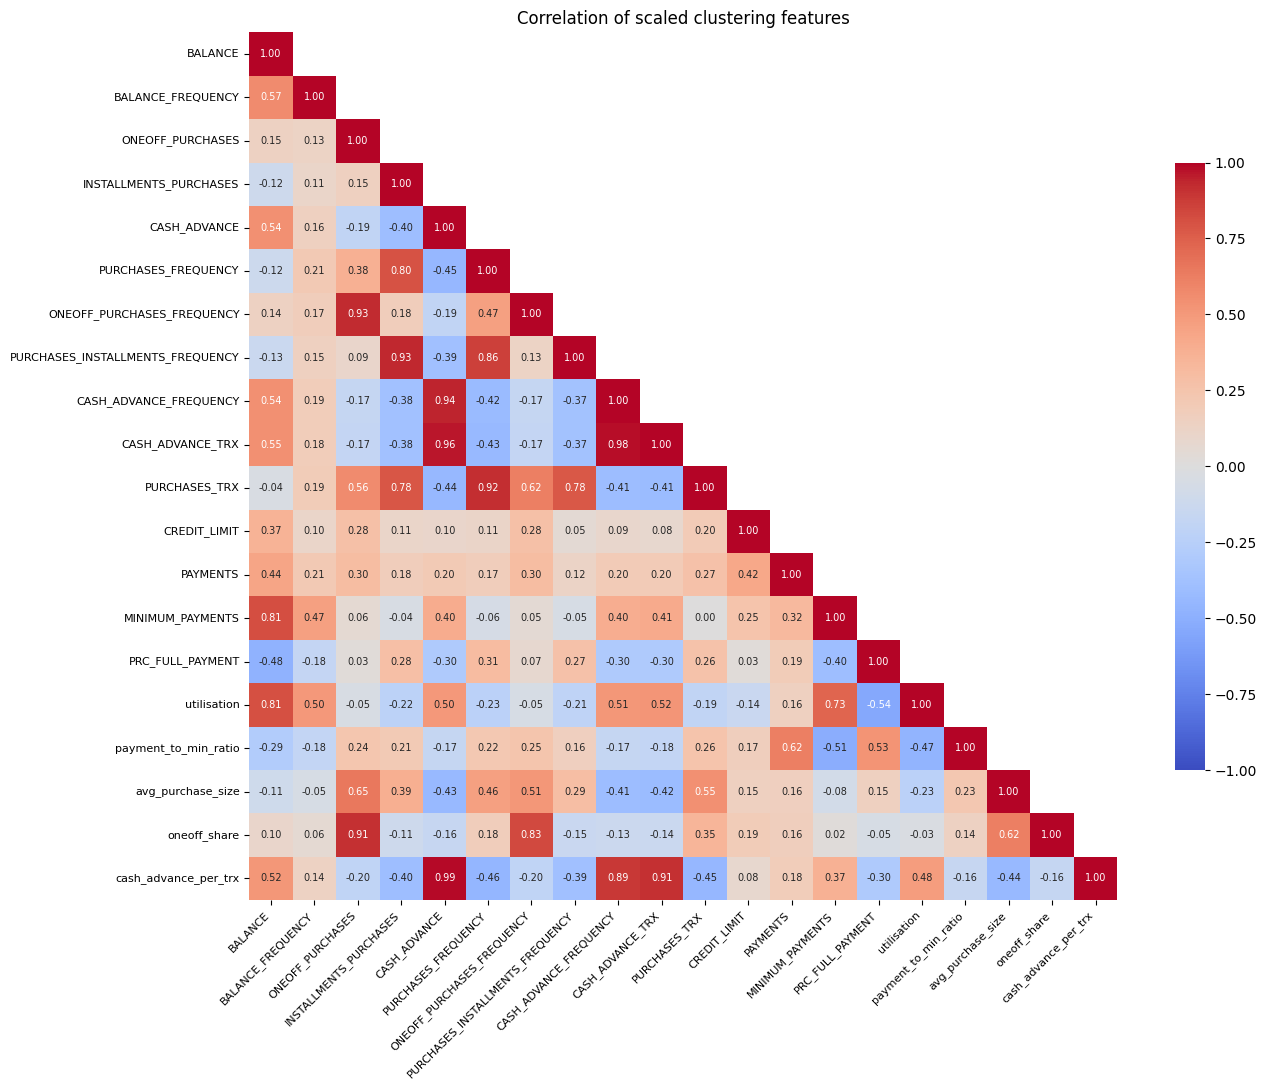


X_scaled ready: (8950, 20)


In [11]:
# CELL 9 — Correlation check on the scaled features

corr = X_scaled.corr()
pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
             .stack().sort_values(ascending=False))
print("Feature pairs with |corr| > 0.75 (scaled space):")
print(pairs[pairs.abs() > 0.75].round(2).to_string())

plt.figure(figsize=(14, 11))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool), k=1),
            annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            annot_kws={"size": 7}, square=True, cbar_kws={"shrink": 0.7})
plt.xticks(rotation=45, ha="right", fontsize=8); plt.yticks(fontsize=8)
plt.title("Correlation of scaled clustering features")
plt.tight_layout(); plt.show()

print("\nX_scaled ready:", X_scaled.shape)

### Step 12 · Apply three decisions and rebuild the analysis table
Based on Steps 5, 6 and 11, three changes are made and the scaled table is rebuilt from scratch:

1. **Missing minimum payment → 0** for the 313 dormant cards (they have nothing to repay), instead of the overall median.
2. **Drop three redundant count columns** — `cash_advance_per_trx`, `CASH_ADVANCE_TRX`, `PURCHASES_TRX` — keeping the *amount* and *how often* version of each behaviour.
3. **Cap `oneoff_share` at 1** to neutralise the 19 rows with inconsistent purchase totals.

**What we saw.** The final clustering table has 8,950 customers × 17 variables. Some strong correlations remain (e.g. installment amount vs installment frequency, 0.93) but these are *different* facts about the same behaviour and are handled by the compression step in Phase 4 rather than by deleting columns.

> **Technical note.** Everything downstream (`X_scaled`, `feat`, `cluster_features`) is redefined here; Steps 8–11 are retained as the evidence trail for the decisions.


In [12]:
# CELL 10 — Apply the three decisions and rebuild X_scaled

from sklearn.preprocessing import PowerTransformer

df2 = raw.copy()
cust_id = df2.pop("CUST_ID")
df2["min_payment_missing"] = df2["MINIMUM_PAYMENTS"].isna().astype(int)
df2["MINIMUM_PAYMENTS"] = df2["MINIMUM_PAYMENTS"].fillna(0.0)                  # decision 1
df2["CREDIT_LIMIT"]     = df2["CREDIT_LIMIT"].fillna(df2["CREDIT_LIMIT"].median())
for col in freq_cols:
    df2[col] = df2[col].clip(0, 1)

feat = df2.copy()
feat["utilisation"]          = safe_ratio(feat["BALANCE"], feat["CREDIT_LIMIT"])
feat["payment_to_min_ratio"] = safe_ratio(feat["PAYMENTS"], feat["MINIMUM_PAYMENTS"])
feat["avg_purchase_size"]    = safe_ratio(feat["PURCHASES"], feat["PURCHASES_TRX"])
feat["oneoff_share"]         = np.clip(safe_ratio(feat["ONEOFF_PURCHASES"], feat["PURCHASES"]), 0, 1)  # decision 3

profile_only = ["TENURE", "min_payment_missing", "PURCHASES"]
dropped_redundant = ["CASH_ADVANCE_TRX", "PURCHASES_TRX"]                       # decision 2 (cash_advance_per_trx never created)
cluster_features = [c for c in feat.columns if c not in profile_only + dropped_redundant]

X_raw = feat[cluster_features].copy()
pt = PowerTransformer(method="yeo-johnson", standardize=True)
X_scaled = pd.DataFrame(pt.fit_transform(X_raw), columns=cluster_features, index=X_raw.index)

print("Final clustering features ({}):".format(len(cluster_features)))
print(cluster_features)
print("\nX_scaled shape:", X_scaled.shape)
print("\nMax |corr| pairs remaining (> 0.75):")
corr = X_scaled.corr()
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print(pairs[pairs.abs() > 0.75].sort_values(ascending=False).round(2).to_string())

Final clustering features (17):
['BALANCE', 'BALANCE_FREQUENCY', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'utilisation', 'payment_to_min_ratio', 'avg_purchase_size', 'oneoff_share']

X_scaled shape: (8950, 17)

Max |corr| pairs remaining (> 0.75):
CASH_ADVANCE                CASH_ADVANCE_FREQUENCY             0.940
INSTALLMENTS_PURCHASES      PURCHASES_INSTALLMENTS_FREQUENCY   0.930
ONEOFF_PURCHASES            ONEOFF_PURCHASES_FREQUENCY         0.930
                            oneoff_share                       0.910
PURCHASES_FREQUENCY         PURCHASES_INSTALLMENTS_FREQUENCY   0.860
ONEOFF_PURCHASES_FREQUENCY  oneoff_share                       0.830
BALANCE                     utilisation                        0.810
INSTALLMENTS_PURCHASES      PURCHASES_FREQUENCY                0.

## Phase 3 — Does the data have groups, and what shape are they?

Before choosing a grouping method it is worth asking three questions the data can answer on its own: *Is there any group structure at all?* *How many independent dimensions of behaviour are there?* *Is the structure "straight" (linear) or "curved" (non-linear)?* The answer to the third decides whether a simple, explainable method is enough or whether a more complex one is warranted.

### Step 13 · Is there any structure to find? (Hopkins statistic)
The Hopkins test compares the real data with randomly scattered points. A score of 0.5 means the customers are spread as evenly as random noise (no groups to find); a score near 1 means they clump.

**What we saw.** Hopkins = 0.855. The data clumps strongly. Segmentation is a meaningful exercise, not an artefact of the algorithm.


In [13]:
# CELL 11 — Cluster tendency: Hopkins statistic

from sklearn.neighbors import NearestNeighbors

def hopkins(X, sample_size=500, n_rep=10, seed=RANDOM_STATE):
    """Hopkins statistic. ~0.5 = uniform random (no structure); >0.75 = clusterable."""
    X = np.asarray(X); rng = np.random.RandomState(seed)
    n, d = X.shape
    lo, hi = X.min(axis=0), X.max(axis=0)
    nn = NearestNeighbors(n_neighbors=2).fit(X)
    vals = []
    for _ in range(n_rep):
        idx = rng.choice(n, sample_size, replace=False)
        real = X[idx]
        synth = rng.uniform(lo, hi, size=(sample_size, d))
        w = nn.kneighbors(real, n_neighbors=2)[0][:, 1]      # exclude self
        u = nn.kneighbors(synth, n_neighbors=1)[0][:, 0]
        vals.append(u.sum() / (u.sum() + w.sum()))
    return np.mean(vals), np.std(vals)

h_mean, h_std = hopkins(X_scaled.values)
print(f"Hopkins statistic: {h_mean:.3f} ± {h_std:.3f}   (0.5 = no structure, >0.75 = clusterable)")

Hopkins statistic: 0.855 ± 0.003   (0.5 = no structure, >0.75 = clusterable)


### Step 14 · How many independent dimensions of behaviour are there? (Principal Component Analysis)
Seventeen variables sound like seventeen dimensions, but many overlap. PCA finds the underlying "directions" along which customers actually differ and reports how much of the total variation each direction explains. It also tells us *what* each direction means, through the "loadings" (which original variables contribute to it).

**What we saw.**
- The first 4 directions explain 77% of all variation; 7 explain 91%; the remaining 10 add only 9% between them and are mostly noise.
- The first four directions have clear business meanings:
  - **PC1** – cash-advance / high-utilisation behaviour *versus* frequent installment purchasing;
  - **PC2** – overall account size (balance, one-off purchases, payments, minimum payments);
  - **PC3** – installment buying *versus* one-off buying;
  - **PC4** – repayment quality (payment-to-minimum ratio, share of months paid in full, credit limit).

These four themes are the vocabulary the final segments will be described in.

> **Technical note.** Two conventional cut-offs disagree slightly: the Kaiser rule (eigenvalue > 1) says 4 components, the 90%-variance rule says 7. We take 7 to preserve the repayment-quality signal, and check in Step 25 that the choice does not matter much.


In [14]:
# CELL 12 — PCA: variance by component and loadings of the first 4

from sklearn.decomposition import PCA

pca_full = PCA(random_state=RANDOM_STATE).fit(X_scaled)
evr = pca_full.explained_variance_ratio_
var_table = pd.DataFrame({
    "component": np.arange(1, len(evr) + 1),
    "variance_%": (evr * 100).round(1),
    "cumulative_%": (np.cumsum(evr) * 100).round(1),
    "eigenvalue": pca_full.explained_variance_.round(2),
})
print(var_table.to_string(index=False))

n_90 = int(np.argmax(np.cumsum(evr) >= 0.90) + 1)
n_kaiser = int((pca_full.explained_variance_ > 1).sum())
print(f"\nComponents for >=90% variance: {n_90}")
print(f"Kaiser rule (eigenvalue > 1):  {n_kaiser}")

loadings = pd.DataFrame(pca_full.components_[:4].T,
                        index=cluster_features, columns=[f"PC{i}" for i in range(1, 5)])
print("\nLoadings of first 4 components (|loading| >= 0.25 shown):")
print(loadings.where(loadings.abs() >= 0.25).round(2).fillna("").to_string())

 component  variance_%  cumulative_%  eigenvalue
         1      29.800        29.800       5.070
         2      22.800        52.600       3.880
         3      14.000        66.600       2.380
         4      10.800        77.400       1.840
         5       5.100        82.600       0.870
         6       4.700        87.200       0.800
         7       3.800        91.100       0.650
         8       2.800        93.800       0.470
         9       2.300        96.100       0.390
        10       1.100        97.300       0.190
        11       0.800        98.100       0.130
        12       0.500        98.600       0.080
        13       0.500        99.000       0.080
        14       0.400        99.400       0.060
        15       0.300        99.700       0.040
        16       0.200        99.900       0.040
        17       0.100       100.000       0.020

Components for >=90% variance: 7
Kaiser rule (eigenvalue > 1):  4

Loadings of first 4 components (|loading| >= 0.25 

### Step 15 · An independent estimate of dimensionality (TwoNN)
PCA only sees "straight-line" structure. The TwoNN estimator, which looks at distances between each customer and their nearest neighbours, estimates how many dimensions the data occupies regardless of shape. If the two estimates agree, the data lies in a roughly flat region (linear); if TwoNN is far lower than PCA, the data is curled up on a curved surface (non-linear) and PCA would be wasting dimensions describing the curve.

**What we saw.** TwoNN says 5.4 dimensions; PCA needs 7 for 90% of variance. These agree closely. First piece of evidence that the structure is linear.

> **Technical note.** Facco et al. (2017). The estimator uses the ratio of second- to first-nearest-neighbour distance, discarding the top 10% of ratios as outliers.


In [15]:
# CELL 13 — Intrinsic dimension (TwoNN estimator)

def twonn_intrinsic_dim(X, discard_frac=0.1, seed=RANDOM_STATE):
    """Facco et al. 2017. Uses ratio of 2nd to 1st nearest-neighbour distances."""
    X = np.asarray(X)
    nn = NearestNeighbors(n_neighbors=3).fit(X)
    d, _ = nn.kneighbors(X)
    r1, r2 = d[:, 1], d[:, 2]
    ok = r1 > 0
    mu = np.sort(r2[ok] / r1[ok])
    n = len(mu)
    mu = mu[: int(n * (1 - discard_frac))]          # drop largest ratios (outliers)
    F = np.arange(1, len(mu) + 1) / n
    x = np.log(mu); y = -np.log(1 - F)
    slope = np.sum(x * y) / np.sum(x * x)             # fit through origin
    return slope

id_est = twonn_intrinsic_dim(X_scaled.values)
print(f"TwoNN intrinsic dimension: {id_est:.1f}")
print(f"PCA components for 90% variance: {n_90}")
print("Reading: if these are close, the data sits in a roughly flat subspace (linear).")
print("         If intrinsic dim << PCA dim, there is a curved manifold (non-linear).")

TwoNN intrinsic dimension: 5.4
PCA components for 90% variance: 7
Reading: if these are close, the data sits in a roughly flat subspace (linear).
         If intrinsic dim << PCA dim, there is a curved manifold (non-linear).


### Step 16 · The decisive linearity test: does a straight-line summary preserve who is close to whom?
We compress the data to 2, 5, 8 and 10 dimensions three ways — PCA (linear), Kernel PCA (non-linear, curved) and UMAP (non-linear, neighbourhood-based) — and measure "trustworthiness": if two customers are neighbours in the compressed version, were they neighbours in the original 17-variable data? A score of 1 is perfect.

**Why this matters.** The earlier version of this analysis compared methods only in 2 dimensions, where UMAP always looks best because it is designed to draw good 2-D pictures. That is a test of drawing, not of the data's shape. The fair test is at *matched, realistic* dimensions.

**What we saw** (trustworthiness):

| dims | PCA | Kernel PCA | UMAP |
|---|---|---|---|
| 2 | 0.863 | 0.853 | 0.989 |
| 5 | 0.991 | 0.974 | 0.993 |
| 8 | **0.999** | 0.991 | 0.993 |
| 10 | **1.000** | 0.995 | 0.993 |

At 5 dimensions PCA already matches UMAP; at 8 it is essentially perfect and beats UMAP. Kernel PCA never beats plain PCA at any size. **Conclusion: the data is linear.** There is no curved structure for a non-linear method to unfold; UMAP's advantage exists only in 2-D pictures. We will therefore compress with PCA and cluster in that space, and use UMAP only for illustration.

> **Technical note.** Continuity (the reverse question) is also reported and is ≥ 0.98 for all methods at all sizes, so it does not discriminate. Trustworthiness uses k = 10 neighbours on a 3,000-customer subsample for speed. Kernel PCA uses an RBF kernel with default gamma; UMAP uses `min_dist = 0` to favour structure over layout.


In [16]:
# CELL 14 — Neighbourhood preservation at matched dimensions
#           PCA vs Kernel PCA vs UMAP, d = 2, 5, 8, 10   (~2-3 min on CPU)

from sklearn.decomposition import KernelPCA
from sklearn.manifold import trustworthiness
import umap                                  # pip install umap-learn
import time

rng = np.random.RandomState(RANDOM_STATE)
sub = rng.choice(len(X_scaled), 3000, replace=False)     # subsample for speed
Xs = X_scaled.values
K = 10

rows = []
for d in [2, 5, 8, 10]:
    t0 = time.time()
    pca_d  = PCA(n_components=d, random_state=RANDOM_STATE).fit_transform(Xs)
    kpca_d = KernelPCA(n_components=d, kernel="rbf", random_state=RANDOM_STATE, n_jobs=-1).fit_transform(Xs)
    umap_d = umap.UMAP(n_components=d, min_dist=0.0, n_neighbors=15,
                       random_state=RANDOM_STATE).fit_transform(Xs)
    rows.append({
        "dims": d,
        "PCA_trust":  trustworthiness(Xs[sub], pca_d[sub],  n_neighbors=K),
        "KPCA_trust": trustworthiness(Xs[sub], kpca_d[sub], n_neighbors=K),
        "UMAP_trust": trustworthiness(Xs[sub], umap_d[sub], n_neighbors=K),
        "PCA_cont":   trustworthiness(pca_d[sub],  Xs[sub], n_neighbors=K),
        "KPCA_cont":  trustworthiness(kpca_d[sub], Xs[sub], n_neighbors=K),
        "UMAP_cont":  trustworthiness(umap_d[sub], Xs[sub], n_neighbors=K),
    })
    print(f"d={d} done in {time.time()-t0:.0f}s")

geom = pd.DataFrame(rows).set_index("dims").round(3)
print("\nTrustworthiness / continuity (k=10) at matched dimensions:")
print(geom.to_string())
print("\nDecision rule: if PCA_trust >= 0.98 by d ~ intrinsic dimension and is within ~0.01 of UMAP,")
print("the geometry is linear -> cluster in PCA space.")

d=2 done in 57s
d=5 done in 56s
d=8 done in 32s
d=10 done in 157s

Trustworthiness / continuity (k=10) at matched dimensions:
      PCA_trust  KPCA_trust  UMAP_trust  PCA_cont  KPCA_cont  UMAP_cont
dims                                                                   
2         0.863       0.853       0.989     0.975      0.971      0.983
5         0.991       0.974       0.993     0.998      0.994      0.986
8         0.999       0.991       0.993     1.000      0.997      0.986
10        1.000       0.995       0.993     1.000      0.998      0.986

Decision rule: if PCA_trust >= 0.98 by d ~ intrinsic dimension and is within ~0.01 of UMAP,
the geometry is linear -> cluster in PCA space.


## Phase 4 — Compress to the working space

### Step 17 · Fit the 7-dimension PCA space (for clustering) and a 2-D UMAP map (for pictures only)
Following Phase 3, we reduce the 17 scaled variables to 7 PCA dimensions — this is the space in which every grouping method will run. We also fit a 2-D UMAP layout, which will be used *only* to draw the final segments, never to build or score them.

**What we saw.** PCA-7 keeps 91.1% of all variation in the data.


In [17]:
# CELL 15 — Fit PCA-7 (clustering space) and UMAP-2 (plotting only)

N_COMP = 7
pca = PCA(n_components=N_COMP, random_state=RANDOM_STATE).fit(X_scaled)
X_pca = pca.transform(X_scaled)
print(f"PCA-{N_COMP}: {pca.explained_variance_ratio_.sum()*100:.1f}% variance retained, shape {X_pca.shape}")

umap2 = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=RANDOM_STATE)
X_umap2 = umap2.fit_transform(X_scaled)
print("UMAP-2 for plotting:", X_umap2.shape)

PCA-7: 91.1% variance retained, shape (8950, 7)
UMAP-2 for plotting: (8950, 2)


### Step 18 · A single, fair scorecard for every candidate
This helper function is the heart of the fair comparison. Every grouping we try — regardless of which method or which compressed space produced it — is scored in *the same place*: the original 17 scaled variables. Three standard scores are computed:

- **Silhouette** (higher is better; range −1 to 1): how much closer each customer is to their own group than to the nearest other group.
- **Davies–Bouldin** (lower is better): how compact groups are relative to how far apart they sit.
- **Calinski–Harabasz** (higher is better): ratio of between-group to within-group spread.

It also records the share of customers left unassigned (some methods allow "noise") and the size of the smallest group, since a segment too small to target is not useful.

> **Technical note.** Scoring in each method's *own* embedding is invalid: UMAP compresses neighbourhoods and separates blobs by construction, so any labelling inside a UMAP embedding gets an inflated silhouette (0.53 in the earlier analysis vs 0.19 when scored fairly). Silhouette is computed on a fixed 4,000-customer subsample to keep runtime reasonable; DB and CH use all customers.


In [18]:
# CELL 16 — Scoring helper: every labelling is scored in the SAME reference space

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

X_ref = X_scaled.values                      # reference space for all metrics
rng = np.random.RandomState(RANDOM_STATE)
sil_idx = rng.choice(len(X_ref), 4000, replace=False)   # fixed subsample for silhouette (speed)

def score_labels(labels, name, k=None, extra=None):
    labels = np.asarray(labels)
    mask = labels >= 0                                   # drop noise (-1) for metric computation
    n_clusters = len(np.unique(labels[mask]))
    out = {"method": name, "k": k if k is not None else n_clusters,
           "noise_%": round(100 * (1 - mask.mean()), 1),
           "min_cluster_%": round(100 * np.bincount(labels[mask]).min() / len(labels), 1)}
    if n_clusters > 1:
        si = sil_idx[mask[sil_idx]]
        out["silhouette"] = silhouette_score(X_ref[si], labels[si])
        out["davies_bouldin"] = davies_bouldin_score(X_ref[mask], labels[mask])
        out["calinski_harabasz"] = calinski_harabasz_score(X_ref[mask], labels[mask])
    if extra: out.update(extra)
    return out

## Phase 5 — Try the candidate grouping methods

Four methods are tried, each with a range of group counts. They make different assumptions, so together they cover the plausible options:

| Method | Assumes | Good when |
|---|---|---|
| K-Means | Groups are compact and roughly round | Structure is linear and everyone must be assigned |
| Gaussian Mixture (GMM) | Groups are ellipses of possibly different shape | Groups overlap or are stretched |
| Ward hierarchical | Groups form a nested tree | A hierarchy is meaningful |
| HDBSCAN (on UMAP) | Groups are dense regions of any shape; outliers allowed | Structure is non-linear, outliers should be excluded |

### Step 19 · K-Means, 2 to 10 groups
K-Means places *k* centre points and assigns each customer to the nearest one, then moves the centres and repeats. We run it for every *k* from 2 to 10 (20 random restarts each, keeping the best) and score each result.

**What we saw.** Silhouette rises from 0.215 (k=2) to a plateau of 0.242–0.244 at k=5, 6 and 7, then falls. Davies–Bouldin is best (lowest) at k=5–6 (1.48–1.50). Beyond k=7 the smallest group drops below 10% of customers, which is too thin to act on. So the candidate range narrows to **5–7 groups**. The three charts show the same story: the "elbow" in inertia around 4–5, the silhouette peak at 5–7, and the DB trough at 5–6.

> **Technical note.** Absolute silhouette values around 0.24 are normal for behavioural data of this kind — customer behaviour is continuous and groups overlap at the edges. What matters is comparison across methods and *k*, and the checks against chance in Phase 6.


KMeans on PCA-7 (metrics in reference space):
method  k  noise_%  min_cluster_%  silhouette  davies_bouldin  calinski_harabasz     inertia
KMeans  2    0.000         43.300       0.215           1.776          2,582.084 104,491.851
KMeans  3    0.000         28.300       0.229           1.603          2,469.530  84,522.998
KMeans  4    0.000         22.300       0.231           1.693          2,286.210  72,872.654
KMeans  5    0.000         15.800       0.242           1.497          2,152.375  64,490.939
KMeans  6    0.000         11.500       0.242           1.478          2,023.774  58,447.731
KMeans  7    0.000          9.300       0.244           1.489          1,903.332  53,982.503
KMeans  8    0.000          6.300       0.230           1.521          1,817.247  50,076.273
KMeans  9    0.000          4.300       0.229           1.467          1,725.794  47,201.411
KMeans 10    0.000          4.200       0.232           1.464          1,660.147  44,529.536


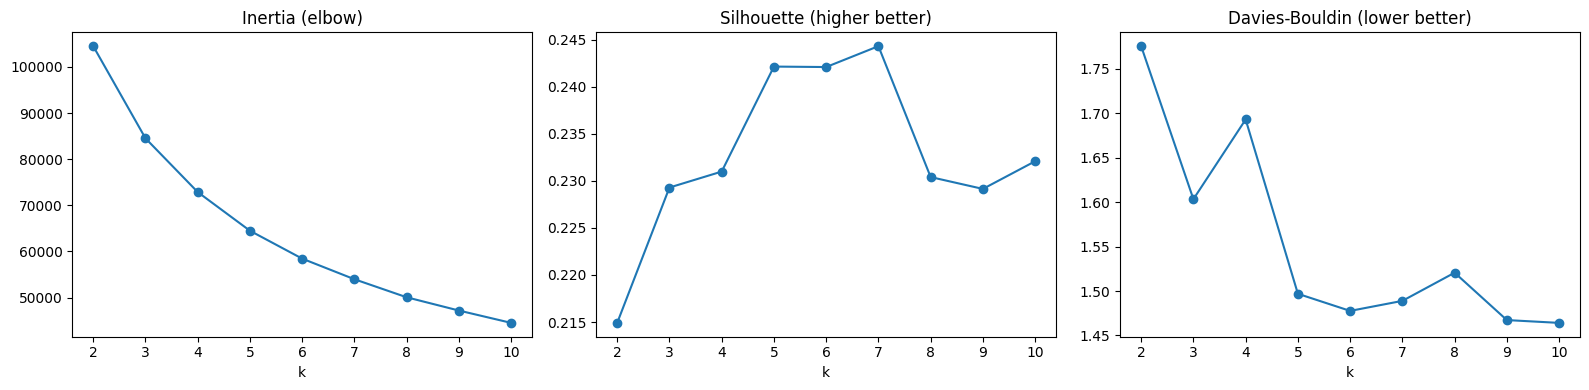

In [19]:
# CELL 17 — KMeans sweep, k = 2..10, in PCA-7

from sklearn.cluster import KMeans

K_RANGE = range(2, 11)
km_models, km_rows = {}, []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(X_pca)
    km_models[k] = km
    km_rows.append(score_labels(km.labels_, "KMeans", k, {"inertia": km.inertia_}))
km_table = pd.DataFrame(km_rows)
print("KMeans on PCA-7 (metrics in reference space):")
print(km_table.round(3).to_string(index=False))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(km_table.k, km_table.inertia, "o-"); ax[0].set_title("Inertia (elbow)"); ax[0].set_xlabel("k")
ax[1].plot(km_table.k, km_table.silhouette, "o-"); ax[1].set_title("Silhouette (higher better)"); ax[1].set_xlabel("k")
ax[2].plot(km_table.k, km_table.davies_bouldin, "o-"); ax[2].set_title("Davies-Bouldin (lower better)"); ax[2].set_xlabel("k")
plt.tight_layout(); plt.show()

### Step 20 · Gaussian Mixture Models, 2 to 10 groups
GMM is a more flexible cousin of K-Means: each group is an ellipse that can be stretched or tilted, and it comes with its own statistic (BIC) for choosing the number of groups.

**What we saw.** GMM scores worse than K-Means at every *k* (best silhouette 0.213 at k=5 vs 0.242 for K-Means). Its BIC keeps improving all the way to k=10 while the silhouette *falls* — a sign the extra ellipses are being spent modelling the lopsided, zero-heavy shape of the data rather than finding customer types. GMM is not the right tool here.


In [20]:
# CELL 18 — Gaussian Mixture sweep (full covariance), BIC picks k

from sklearn.mixture import GaussianMixture

gmm_models, gmm_rows = {}, []
for k in K_RANGE:
    gmm = GaussianMixture(n_components=k, covariance_type="full", n_init=5,
                          random_state=RANDOM_STATE, reg_covar=1e-4).fit(X_pca)
    gmm_models[k] = gmm
    gmm_rows.append(score_labels(gmm.predict(X_pca), "GMM", k, {"bic": gmm.bic(X_pca)}))
gmm_table = pd.DataFrame(gmm_rows)
print("GMM (full covariance) on PCA-7:")
print(gmm_table.round(3).to_string(index=False))
print("\nBIC minimum at k =", int(gmm_table.loc[gmm_table.bic.idxmin(), "k"]))

GMM (full covariance) on PCA-7:
method  k  noise_%  min_cluster_%  silhouette  davies_bouldin  calinski_harabasz         bic
   GMM  2    0.000         47.900       0.194           2.016          2,102.092 189,269.317
   GMM  3    0.000         22.800       0.196           1.851          2,044.203 159,288.034
   GMM  4    0.000         20.600       0.209           1.799          1,858.944 153,541.813
   GMM  5    0.000         15.900       0.213           1.719          1,848.878 146,041.998
   GMM  6    0.000          9.700       0.161           1.881          1,582.245 133,954.443
   GMM  7    0.000          9.700       0.169           1.809          1,535.300 130,310.476
   GMM  8    0.000          9.000       0.145           2.185          1,245.989 128,713.231
   GMM  9    0.000          7.400       0.153           2.124          1,236.589 124,946.546
   GMM 10    0.000          2.700       0.139           1.966          1,232.289 124,894.946

BIC minimum at k = 10


### Step 21 · Ward hierarchical clustering, 2 to 8 groups
Ward's method starts with every customer as their own group and repeatedly merges the two closest groups. It is useful when a tree of segments-within-segments is wanted.

**What we saw.** Consistently below K-Means (silhouette 0.19–0.22), with a persistent small group of 10% or less. Not the right tool either.


In [21]:
# CELL 19 — Agglomerative (Ward) sweep, k = 2..8, in PCA-7

from sklearn.cluster import AgglomerativeClustering

ward_rows, ward_labels = [], {}
for k in range(2, 9):
    lab = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X_pca)
    ward_labels[k] = lab
    ward_rows.append(score_labels(lab, "Ward", k))
ward_table = pd.DataFrame(ward_rows)
print("Ward agglomerative on PCA-7:")
print(ward_table.round(3).to_string(index=False))

Ward agglomerative on PCA-7:
method  k  noise_%  min_cluster_%  silhouette  davies_bouldin  calinski_harabasz
  Ward  2    0.000         20.600       0.196           1.427          1,969.852
  Ward  3    0.000         20.600       0.192           1.776          1,870.920
  Ward  4    0.000         20.600       0.211           1.826          1,851.674
  Ward  5    0.000         10.100       0.202           1.654          1,708.630
  Ward  6    0.000         10.100       0.198           1.623          1,641.199
  Ward  7    0.000         10.100       0.208           1.640          1,626.404
  Ward  8    0.000          4.700       0.216           1.575          1,558.284


### Step 22 · HDBSCAN on UMAP — the "non-linear" alternative, run as a diagnostic
This is the combination the earlier analysis pointed to. HDBSCAN finds dense regions of any shape and can leave customers unassigned as "noise". We run it in a 5-dimensional UMAP space (not 2-D, to give it a fair chance) with four settings for minimum group size, and score the results in the same reference space as everything else.

**What we saw.** With small minimum-group sizes it finds 11–17 groups, many of them 1–5% of customers — too fragmented to use. Only when forced (minimum group 800) does it return a marketable 5 groups, and even then it scores below K-Means-5 on every measure (silhouette 0.217 vs 0.242; DB 1.63 vs 1.50). This confirms Phase 3: there is no non-linear structure for it to exploit, and the "islands" it finds are the zero-inflation patterns from Step 7.


In [22]:
# CELL 20 — HDBSCAN on UMAP-5 (diagnostic track)

from sklearn.cluster import HDBSCAN

umap5 = umap.UMAP(n_components=5, n_neighbors=30, min_dist=0.0, random_state=RANDOM_STATE)
X_umap5 = umap5.fit_transform(X_scaled)

hdb_rows, hdb_labels = [], {}
for mcs in [100, 200, 400, 800]:
    hdb = HDBSCAN(min_cluster_size=mcs, min_samples=10).fit(X_umap5)
    hdb_labels[mcs] = hdb.labels_
    hdb_rows.append(score_labels(hdb.labels_, f"HDBSCAN(mcs={mcs})"))
hdb_table = pd.DataFrame(hdb_rows)
print("HDBSCAN on UMAP-5 (metrics in reference space, noise excluded):")
print(hdb_table.round(3).to_string(index=False))

HDBSCAN on UMAP-5 (metrics in reference space, noise excluded):
          method  k  noise_%  min_cluster_%  silhouette  davies_bouldin  calinski_harabasz
HDBSCAN(mcs=100) 17    1.900          1.100       0.164           1.550          1,007.346
HDBSCAN(mcs=200) 12    2.200          2.600       0.159           1.640          1,226.972
HDBSCAN(mcs=400) 11    2.100          4.600       0.161           1.725          1,274.744
HDBSCAN(mcs=800)  5    0.000         12.900       0.217           1.632          1,859.027


### Step 23 · Does the number of PCA dimensions matter? (5 vs 7 vs 9)
We re-run K-Means in 5- and 9-dimension PCA spaces and check whether the customers end up in the same groups as in the 7-dimension space (Adjusted Rand Index, ARI: 1 = identical grouping, 0 = no better than random).

**What we saw.** ARI between 0.81 and 0.99 in every case, and scores identical to two decimals. The choice of 7 dimensions is not driving the result; anything from 5 to 9 gives the same segmentation.


In [23]:
# CELL 21 — Robustness of KMeans to the number of PCA components (5 / 7 / 9)

from sklearn.metrics import adjusted_rand_score

rob_rows = []
for d in [5, 7, 9]:
    Xd = PCA(n_components=d, random_state=RANDOM_STATE).fit_transform(X_scaled)
    for k in [3, 4, 5, 6]:
        lab = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit_predict(Xd)
        r = score_labels(lab, f"KMeans d={d}", k)
        r["ARI_vs_d7"] = adjusted_rand_score(km_models[k].labels_, lab)
        rob_rows.append(r)
rob_table = pd.DataFrame(rob_rows)
print("KMeans across PCA dimensionality (ARI_vs_d7 = agreement with the d=7 solution):")
print(rob_table.round(3).to_string(index=False))

KMeans across PCA dimensionality (ARI_vs_d7 = agreement with the d=7 solution):
    method  k  noise_%  min_cluster_%  silhouette  davies_bouldin  calinski_harabasz  ARI_vs_d7
KMeans d=5  3    0.000         28.400       0.228           1.606          2,468.194      0.974
KMeans d=5  4    0.000         22.100       0.230           1.697          2,280.089      0.951
KMeans d=5  5    0.000         16.500       0.242           1.522          2,145.648      0.885
KMeans d=5  6    0.000         11.300       0.246           1.486          2,021.314      0.807
KMeans d=7  3    0.000         28.300       0.229           1.603          2,469.530      1.000
KMeans d=7  4    0.000         22.300       0.231           1.693          2,286.210      1.000
KMeans d=7  5    0.000         15.800       0.242           1.497          2,152.375      1.000
KMeans d=7  6    0.000         11.500       0.242           1.478          2,023.774      1.000
KMeans d=9  3    0.000         28.300       0.229       

### Step 24 · Leaderboard — every candidate, one scorecard
All 29 candidates side by side, scored in the same reference space, sorted by silhouette.

**What we saw.** The top eight rows are all K-Means. The best non-K-Means result (HDBSCAN with min size 800, and Ward with 8 groups) sits below K-Means with just 2 groups. **K-Means in PCA space is the method.** The number of groups is still open between 5, 6 and 7 on these scores, with 4 kept in as the "simplest defensible" option — Phase 6 settles it.


In [24]:
# CELL 22 — Combined leaderboard

leader = pd.concat([km_table, gmm_table, ward_table, hdb_table], ignore_index=True)
cols = ["method", "k", "noise_%", "min_cluster_%", "silhouette", "davies_bouldin", "calinski_harabasz"]
leader = leader[cols].sort_values("silhouette", ascending=False)
print("All candidates, scored in the same reference space:")
print(leader.round(3).to_string(index=False))

All candidates, scored in the same reference space:
          method  k  noise_%  min_cluster_%  silhouette  davies_bouldin  calinski_harabasz
          KMeans  7    0.000          9.300       0.244           1.489          1,903.332
          KMeans  5    0.000         15.800       0.242           1.497          2,152.375
          KMeans  6    0.000         11.500       0.242           1.478          2,023.774
          KMeans 10    0.000          4.200       0.232           1.464          1,660.147
          KMeans  4    0.000         22.300       0.231           1.693          2,286.210
          KMeans  8    0.000          6.300       0.230           1.521          1,817.247
          KMeans  3    0.000         28.300       0.229           1.603          2,469.530
          KMeans  9    0.000          4.300       0.229           1.467          1,725.794
HDBSCAN(mcs=800)  5    0.000         12.900       0.217           1.632          1,859.027
            Ward  8    0.000          

## Phase 6 — Stress-test the shortlist (the unsupervised substitute for cross-validation)

In a prediction problem one would hold back some data and check the model on it. There is no "right answer" to check against here, so we use three replacements: **stability** (does the segmentation survive re-sampling the customers?), a **null baseline** (is it better than the same procedure on structure-free data?), and a **linearity check** (can a simple straight-line rule reproduce the groups?). Shortlist: k = 4, 5, 6 and 7.

### Step 25 · Bootstrap stability
Thirty times over, we draw a random sample of customers (with replacement), re-fit K-Means from scratch, use that model to label *all* customers, and compare with the original labels using ARI. A segmentation that only exists for one particular sample is not a segmentation.

**What we saw.**

| k | average agreement | worst case | spread |
|---|---|---|---|
| 4 | 0.923 | 0.547 | 0.125 |
| 5 | 0.892 | **0.783** | **0.048** |
| 6 | 0.848 | 0.637 | 0.124 |
| 7 | 0.893 | 0.677 | 0.105 |

k=4 has the highest *average* but the worst *worst case* — there are two competing ways to cut the data into four, and resamples flip between them. k=5 is the most consistent: tight spread and never below 0.78. k=6 is the least stable of the shortlist.


In [25]:
# CELL 24 — Bootstrap stability of KMeans solutions (the CV substitute)

from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

SHORTLIST = [4, 5, 6, 7]
N_BOOT = 30
rng = np.random.RandomState(RANDOM_STATE)
n = len(X_pca)

stab_rows = []
for k in SHORTLIST:
    ref_labels = km_models[k].labels_
    aris, amis = [], []
    for b in range(N_BOOT):
        idx = rng.choice(n, n, replace=True)
        km_b = KMeans(n_clusters=k, n_init=5, random_state=b).fit(X_pca[idx])
        pred = km_b.predict(X_pca)                    # label ALL points with the bootstrap model
        aris.append(adjusted_rand_score(ref_labels, pred))
        amis.append(adjusted_mutual_info_score(ref_labels, pred))
    stab_rows.append({"k": k, "ARI_mean": np.mean(aris), "ARI_min": np.min(aris),
                      "AMI_mean": np.mean(amis), "ARI_std": np.std(aris)})
stab_table = pd.DataFrame(stab_rows)
print(f"Bootstrap stability ({N_BOOT} resamples, refit and re-predict all customers):")
print(stab_table.round(3).to_string(index=False))
print("\nRule of thumb: ARI_mean >= 0.80 stable, 0.65-0.80 moderately stable, < 0.65 unstable.")

Bootstrap stability (30 resamples, refit and re-predict all customers):
 k  ARI_mean  ARI_min  AMI_mean  ARI_std
 4     0.923    0.547     0.912    0.125
 5     0.892    0.783     0.879    0.048
 6     0.848    0.637     0.849    0.124
 7     0.893    0.677     0.896    0.105

Rule of thumb: ARI_mean >= 0.80 stable, 0.65-0.80 moderately stable, < 0.65 unstable.


### Step 26 · Sensitivity to the random starting point
K-Means starts from random centres; a good solution should be reached from most starting points. Twenty single-start runs are compared with the best-of-20 solution.

**What we saw.** k=5 reaches essentially the same solution most often (average ARI 0.90, highest of the four). k=4 confirms the two-competing-partitions problem: only half of its runs land near the reference solution.


In [26]:
# CELL 25 — Seed sensitivity (does KMeans land on the same solution from different starts?)

seed_rows = []
for k in SHORTLIST:
    ref_labels = km_models[k].labels_
    aris = [adjusted_rand_score(ref_labels,
                                KMeans(n_clusters=k, n_init=1, random_state=s).fit_predict(X_pca))
            for s in range(20)]
    seed_rows.append({"k": k, "ARI_vs_ref_mean": np.mean(aris), "ARI_vs_ref_min": np.min(aris),
                      "share_runs_ARI>0.9": np.mean(np.array(aris) > 0.9)})
print("Seed sensitivity (20 single-init runs vs the n_init=20 solution):")
print(pd.DataFrame(seed_rows).round(3).to_string(index=False))

Seed sensitivity (20 single-init runs vs the n_init=20 solution):
 k  ARI_vs_ref_mean  ARI_vs_ref_min  share_runs_ARI>0.9
 4            0.780           0.555               0.500
 5            0.898           0.591               0.400
 6            0.811           0.600               0.400
 7            0.785           0.690               0.250


### Step 27 · Null baseline — what would these scores be on data with no structure?
We shuffle every column independently. Each variable keeps exactly the same distribution, but the *relationships* between variables are destroyed — there are no customer types left to find. Then we run the identical pipeline and compare scores.

**What we saw.** On shuffled data the silhouette is 0.034–0.037; on the real data it is 0.231–0.244, i.e. **6–7 times higher**. Davies–Bouldin is 1.5 real vs 3.3–3.8 shuffled. The structure we are finding is real, not something the algorithm would produce on any table of numbers.


In [27]:
# CELL 26 — Null baseline: same pipeline on structure-free data
#           (each column shuffled independently -> marginals kept, correlations destroyed)

null_rows = []
for rep in range(5):
    Xn = X_scaled.apply(lambda c: rng.permutation(c.values)).values
    Xn_pca = PCA(n_components=N_COMP, random_state=RANDOM_STATE).fit_transform(Xn)
    for k in SHORTLIST:
        lab = KMeans(n_clusters=k, n_init=5, random_state=rep).fit_predict(Xn_pca)
        null_rows.append({"k": k, "rep": rep,
                          "silhouette_null": silhouette_score(Xn[sil_idx], lab[sil_idx]),
                          "davies_bouldin_null": davies_bouldin_score(Xn, lab)})
null_table = (pd.DataFrame(null_rows).groupby("k")
              .agg(silhouette_null=("silhouette_null", "mean"),
                   davies_bouldin_null=("davies_bouldin_null", "mean")).reset_index())
null_table = null_table.merge(km_table[["k", "silhouette", "davies_bouldin"]], on="k")
null_table["sil_real_vs_null"] = null_table.silhouette / null_table.silhouette_null
print("Real vs null (column-shuffled) data:")
print(null_table[["k", "silhouette", "silhouette_null", "sil_real_vs_null",
                  "davies_bouldin", "davies_bouldin_null"]].round(3).to_string(index=False))

Real vs null (column-shuffled) data:
 k  silhouette  silhouette_null  sil_real_vs_null  davies_bouldin  davies_bouldin_null
 4       0.231            0.037             6.198           1.693                3.813
 5       0.242            0.035             6.841           1.497                3.556
 6       0.242            0.034             7.038           1.478                3.380
 7       0.244            0.034             7.092           1.489                3.251


### Step 28 · Linearity check — can a straight-line rule reproduce the segments?
A final, decisive test of the "linear vs non-linear" question. We take the segment labels and train two models to predict them from the 17 original variables: a simple linear model (logistic regression) and a flexible non-linear one (gradient boosting), using 5-fold cross-validation. If the linear model does as well, the boundaries between segments are flat planes and no non-linear method could have found anything extra.

**What we saw.** Logistic regression reproduces the segments with **99.0–99.4% accuracy** and actually *beats* gradient boosting by 2–3 points at every *k*. The segment boundaries are linear. This closes the question raised at the start of the project: PCA + K-Means was the right family of tools, and UMAP/Kernel PCA + HDBSCAN would have added complexity without information.


In [28]:
# CELL 27 — Linear vs non-linear boundary check
#           Can a linear classifier reproduce the cluster labels as well as a non-linear one?

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
lin_rows = []
for k in SHORTLIST:
    y = km_models[k].labels_
    acc_lin = cross_val_score(LogisticRegression(max_iter=2000, C=1.0), X_scaled, y,
                              cv=cv, scoring="accuracy").mean()
    acc_gbm = cross_val_score(HistGradientBoostingClassifier(random_state=RANDOM_STATE), X_scaled, y,
                              cv=cv, scoring="accuracy").mean()
    lin_rows.append({"k": k, "logreg_acc": acc_lin, "gbm_acc": acc_gbm, "gap_pts": 100 * (acc_gbm - acc_lin)})
lin_table = pd.DataFrame(lin_rows)
print("Reproducing cluster labels from the 17 scaled features (5-fold CV accuracy):")
print(lin_table.round(3).to_string(index=False))
print("\nReading: gap < ~3 points -> boundaries are linear; a non-linear embedding would add nothing.")

Reproducing cluster labels from the 17 scaled features (5-fold CV accuracy):
 k  logreg_acc  gbm_acc  gap_pts
 4       0.994    0.975   -1.933
 5       0.992    0.966   -2.637
 6       0.990    0.963   -2.737
 7       0.992    0.962   -2.961

Reading: gap < ~3 points -> boundaries are linear; a non-linear embedding would add nothing.


### Step 29 · Phase 6 summary
All stress-test results in one table.

**What we saw and decided.** k=5 combines the best Davies–Bouldin (1.50), a silhouette on the plateau (0.242), the most reliable stability (worst-case ARI 0.78, spread 0.05), a smallest segment of 16%, and linear boundaries. **Five segments is the primary solution.** Four and six are carried into Phase 7 for comparison so the reader can see what merges and what splits.


In [29]:
# CELL 28 — Phase 6 summary table

summary = (km_table[km_table.k.isin(SHORTLIST)][["k", "min_cluster_%", "silhouette", "davies_bouldin"]]
           .merge(stab_table[["k", "ARI_mean", "ARI_min"]], on="k")
           .merge(null_table[["k", "sil_real_vs_null"]], on="k")
           .merge(lin_table[["k", "logreg_acc", "gap_pts"]], on="k"))
print("Phase 6 summary:")
print(summary.round(3).to_string(index=False))

Phase 6 summary:
 k  min_cluster_%  silhouette  davies_bouldin  ARI_mean  ARI_min  sil_real_vs_null  logreg_acc  gap_pts
 4         22.300       0.231           1.693     0.923    0.547             6.198       0.994   -1.933
 5         15.800       0.242           1.497     0.892    0.783             6.841       0.992   -2.637
 6         11.500       0.242           1.478     0.848    0.637             7.038       0.990   -2.737
 7          9.300       0.244           1.489     0.893    0.677             7.092       0.992   -2.961


## Phase 7 — Describe and name the segments

### Step 30 · Attach segment labels to the original customer data
The K-Means labels for k = 4, 5 and 6 are attached to the table of *raw* (untransformed) values, so segments can be described in dollars and frequencies rather than in scaled units. For the primary k=5 solution, segments are renumbered 0–4 from largest to smallest.

**What we saw.** Segment sizes: 2,129 (23.8%), 1,858 (20.8%), 1,782 (19.9%), 1,763 (19.7%) and 1,418 (15.8%). No segment is too small to target and none swallows the population.


In [30]:
# CELL 29 — Assign labels and attach raw variables for profiling

K_PRIMARY = 5
labels = {k: km_models[k].labels_ for k in [4, 5, 6]}

prof = feat.copy()                                    # raw (untransformed) values incl. engineered ratios
prof["CUST_ID"] = cust_id.values
for k in [4, 5, 6]:
    prof[f"cluster_k{k}"] = labels[k]

# Order clusters by size for k=5 so cluster 0 is the largest (cosmetic, stable naming)
order = prof[f"cluster_k{K_PRIMARY}"].value_counts().index.tolist()
remap = {old: new for new, old in enumerate(order)}
prof["segment"] = prof[f"cluster_k{K_PRIMARY}"].map(remap)

sizes = prof["segment"].value_counts().sort_index()
print(f"k={K_PRIMARY} segment sizes:")
print(pd.DataFrame({"n": sizes, "share_%": (100 * sizes / len(prof)).round(1)}).to_string())

k=5 segment sizes:
            n  share_%
segment               
0        2129   23.800
1        1858   20.800
2        1782   19.900
3        1763   19.700
4        1418   15.800


### Step 31 · Profile table — what a typical customer in each segment looks like
For every segment we report the median (typical customer) and the mean (which matters for revenue totals) of the business variables.

**What we saw** (medians unless stated):

| Seg | Share | Balance | Utilisation | Purchases | One-off vs installment | Cash advance | Pays vs minimum | Pays in full |
|---|---|---|---|---|---|---|---|---|
| 0 | 24% | 1,497 | 63% | 0 | — | 1,259 | 1.1× | never |
| 1 | 21% | 43 | 2% | 315 | installment only | 0 | 2.7× | 20% of months |
| 2 | 20% | 2,532 | 71% | 897 | both | 662 | 1.1× | never |
| 3 | 20% | 818 | 31% | 346 | one-off only, large tickets | 0 | 1.6× | never |
| 4 | 16% | 356 | 8% | 1,955 | both, very frequent | 0 | 9.8× | 27% of months |

Each segment differs from the others on at least three variables, which is the test of a usable segmentation.


In [31]:
# CELL 30 — Profile table for k=5: medians and means of the raw business variables

profile_vars = ["BALANCE", "CREDIT_LIMIT", "utilisation", "PURCHASES", "ONEOFF_PURCHASES",
                "INSTALLMENTS_PURCHASES", "PURCHASES_FREQUENCY", "ONEOFF_PURCHASES_FREQUENCY",
                "PURCHASES_INSTALLMENTS_FREQUENCY", "oneoff_share", "avg_purchase_size",
                "CASH_ADVANCE", "CASH_ADVANCE_FREQUENCY", "PAYMENTS", "MINIMUM_PAYMENTS",
                "payment_to_min_ratio", "PRC_FULL_PAYMENT", "BALANCE_FREQUENCY", "TENURE",
                "min_payment_missing"]

median_profile = prof.groupby("segment")[profile_vars].median().T
median_profile["ALL"] = prof[profile_vars].median()
print("Median profile by segment (k=5):")
print(median_profile.round(2).to_string())

mean_profile = prof.groupby("segment")[profile_vars].mean().T
mean_profile["ALL"] = prof[profile_vars].mean()
print("\nMean profile by segment (k=5) — means matter for revenue variables:")
print(mean_profile.round(2).to_string())

Median profile by segment (k=5):
segment                                  0         1         2         3         4       ALL
BALANCE                          1,496.580    42.750 2,532.000   817.710   355.530   873.390
CREDIT_LIMIT                     3,000.000 2,500.000 4,600.000 3,000.000 6,000.000 3,000.000
utilisation                          0.630     0.020     0.710     0.310     0.080     0.300
PURCHASES                            0.000   315.250   897.160   346.320 1,955.440   361.280
ONEOFF_PURCHASES                     0.000     0.000   250.740   325.800 1,092.470    38.000
INSTALLMENTS_PURCHASES               0.000   300.000   439.420     0.000   584.060    89.000
PURCHASES_FREQUENCY                  0.000     0.750     0.880     0.170     1.000     0.500
ONEOFF_PURCHASES_FREQUENCY           0.000     0.000     0.170     0.170     0.580     0.080
PURCHASES_INSTALLMENTS_FREQUENCY     0.000     0.710     0.710     0.000     0.670     0.170
oneoff_share                         

### Step 32 · What makes each segment distinctive?
The same profile in standardised units: 0 is the overall average, +1 is one standard deviation above average, −1 one below. The heat-map makes the pattern visible at a glance, and the list under it names the five strongest distinguishing features of each segment.

**What we saw.**
- **Segment 0** – cash advance far above average (+1.0), every purchase measure far below (−1.0 to −1.4).
- **Segment 1** – balance and utilisation far below average (−1.0 to −1.1), no cash advance, no one-off buying.
- **Segment 2** – highest balance, minimum payment and utilisation (+0.9), heavy installment buying, some cash advance.
- **Segment 3** – one-off share the highest of any segment (+1.3), large average purchase (+0.8), no installments (−0.9).
- **Segment 4** – frequent one-off purchases (+1.2), pays many multiples of the minimum (+1.1), pays in full often (+0.9), low utilisation (−0.7).


Segment mean in scaled units (0 = overall average; ±1 = one SD away):
segment                               0      1      2      3      4
BALANCE                           0.480 -1.130  0.920 -0.100 -0.280
BALANCE_FREQUENCY                 0.090 -0.550  0.540 -0.220  0.190
ONEOFF_PURCHASES                 -0.990 -0.860  0.390  0.800  1.130
INSTALLMENTS_PURCHASES           -1.010  0.710  0.770 -0.890  0.730
CASH_ADVANCE                      1.000 -0.840  0.420 -0.220 -0.670
PURCHASES_FREQUENCY              -1.240  0.500  0.710 -0.480  0.920
ONEOFF_PURCHASES_FREQUENCY       -0.900 -0.810  0.370  0.570  1.230
PURCHASES_INSTALLMENTS_FREQUENCY -0.960  0.760  0.750 -0.900  0.620
CASH_ADVANCE_FREQUENCY            0.940 -0.790  0.420 -0.200 -0.650
CREDIT_LIMIT                     -0.120 -0.400  0.280 -0.180  0.580
PAYMENTS                         -0.030 -0.600  0.410 -0.330  0.730
MINIMUM_PAYMENTS                  0.250 -0.760  0.960 -0.220 -0.310
PRC_FULL_PAYMENT                 -0.400  0.690

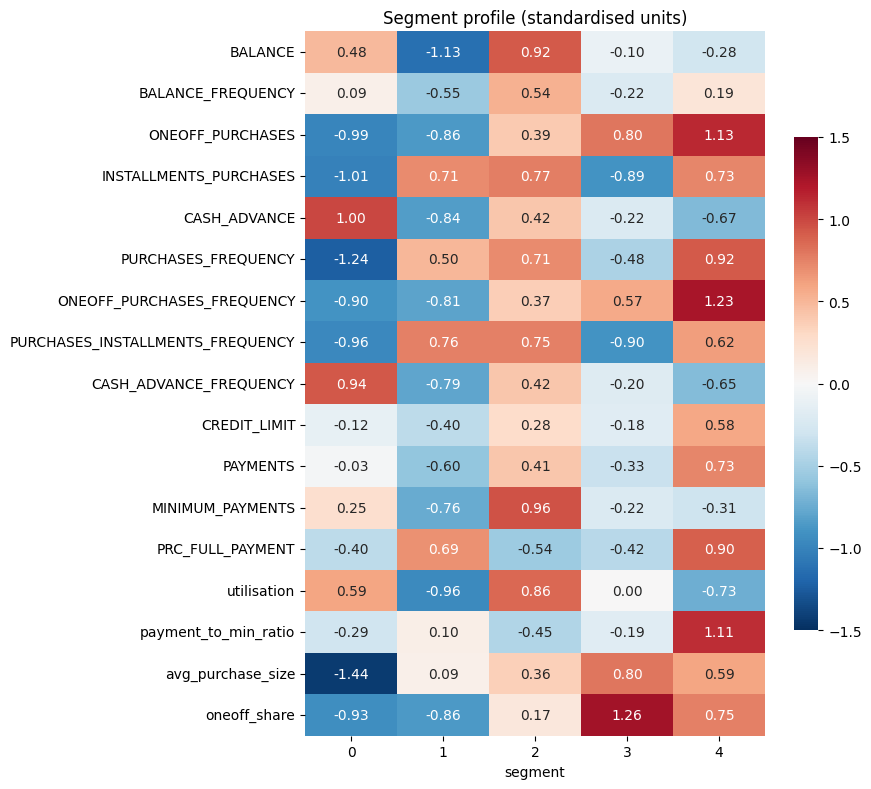

In [32]:
# CELL 31 — What makes each segment distinctive? (segment means in scaled space)

Z = X_scaled.copy()
Z["segment"] = prof["segment"].values
zprof = Z.groupby("segment").mean().T                 # scaled features have mean 0, sd 1 overall
print("Segment mean in scaled units (0 = overall average; ±1 = one SD away):")
print(zprof.round(2).to_string())

print("\nTop distinguishing features per segment:")
for s in zprof.columns:
    top = zprof[s].abs().sort_values(ascending=False).head(5).index
    desc = ", ".join(f"{f} ({zprof.loc[f, s]:+.2f})" for f in top)
    print(f"  Segment {s}: {desc}")

plt.figure(figsize=(9, 8))
sns.heatmap(zprof, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1.5, vmax=1.5,
            cbar_kws={"shrink": 0.7})
plt.title("Segment profile (standardised units)"); plt.tight_layout(); plt.show()

### Step 33 · How the 4- and 6-segment solutions relate to the 5-segment one
Cross-tables showing where each of the five segments' customers land under k=4 and k=6.

**What we saw.**
- **k=4 is not simply "five with two merged".** It splits Segment 3 (occasional big-ticket buyers) almost exactly in half, sending 866 to join the heavy users and 864 to join the transactors, based on balance. That destroys a clean, actionable segment — and it is exactly the instability seen in Step 25.
- **k=6 splits Segment 2** (maxed-out heavy users) into an installment-heavy half (774) and a cash-advance-heavy half (862), and peels 573 customers off Segment 3 with them. Defensible, but the resulting sub-segments are 6–10% each and would receive the same treatment, so it is complexity without a new decision.

Five remains the best trade-off between detail and usability.


In [33]:
# CELL 32 — How k=4 and k=6 relate to k=5 (what merges, what splits)

print("k=5 segments (rows) vs k=4 clusters (columns) — row counts:")
print(pd.crosstab(prof["segment"], prof["cluster_k4"]).to_string())
print("\nk=5 segments (rows) vs k=6 clusters (columns) — row counts:")
print(pd.crosstab(prof["segment"], prof["cluster_k6"]).to_string())

k=5 segments (rows) vs k=4 clusters (columns) — row counts:
cluster_k4     0     1     2     3
segment                           
0              9     0     3  2117
1              0    40  1799    19
2           1622     0   139    21
3            866   864    14    19
4            121  1254    43     0

k=5 segments (rows) vs k=6 clusters (columns) — row counts:
cluster_k6     0     1     2     3    4    5
segment                                     
0           2061     0     0     9   48   11
1              0    20     9  1635  194    0
2              3     0   143     0  774  862
3              8  1158    10     0   14  573
4              0   120  1256    11    0   31


### Step 34 · Sanity check against simple behaviour flags
Share of each segment that ever buys, ever takes a cash advance, ever pays in full, and carries the dormant flag.

**What we saw.** The segments line up with plain-language behaviour: 99% of Segment 0 takes cash advances and only 6% buys anything; 97–100% of Segments 1–4 buy; 73% of Segment 4 and 62% of Segment 1 pay in full at some point, versus 10–18% elsewhere; the dormant flag concentrates in Segments 1 and 3.


In [34]:
# CELL 33 — Usage-pattern check: does each segment map to a purchase/cash-advance behaviour?

prof["uses_purchases"]    = (prof["PURCHASES"] > 0).astype(int)
prof["uses_cash_advance"] = (prof["CASH_ADVANCE"] > 0).astype(int)
prof["pays_in_full_ever"] = (prof["PRC_FULL_PAYMENT"] > 0).astype(int)
print("Share of customers in each segment with the behaviour (%):")
print((100 * prof.groupby("segment")[["uses_purchases", "uses_cash_advance",
                                       "pays_in_full_ever", "min_payment_missing"]].mean()).round(1).to_string())

Share of customers in each segment with the behaviour (%):
         uses_purchases  uses_cash_advance  pays_in_full_ever  min_payment_missing
segment                                                                           
0                 6.200             99.200             18.400                3.100
1                97.500              6.500             62.100                7.200
2               100.000             67.100             10.400                0.300
3               100.000             38.600             15.700                6.200
4               100.000             15.200             73.300                0.100


### Step 35 · Pictures of the segmentation
Left: the 2-D UMAP layout coloured by segment. Right: the first two PCA dimensions — the space the segments were actually built in — coloured the same way.

**What we saw and how to read it.**
- **Right panel (PCA).** Five adjacent, roughly convex regions with straight-ish boundaries — exactly what the 99% linear-model result in Step 28 predicted. Left-to-right is "purchase-driven vs cash-advance-driven"; bottom-to-top is "small account vs large account".
- **Left panel (UMAP).** Segments 0 and 1 form clean islands; Segments 2, 3 and 4 appear "mixed" across several islands. This is not a flaw. Each UMAP island is one *combination of channels used* (one-off? installments? cash advance?) — a follow-up check found every island is 97–100% pure on that basis. Segments 2, 3 and 4 are separated by *how much* and *how they repay*, which are continuous dimensions that cut across those islands. UMAP shows the data's discrete structure well; the PCA panel shows the segmentation honestly. They answer different questions.

> **Technical note.** This is also why HDBSCAN reported 11–17 clusters in Step 22: it was finding UMAP's islands (and UMAP's artificial sub-splits of the installment-only and one-off-only groups), not customer types. The islands can be reproduced with three `> 0` checks and needed no non-linear method to discover.


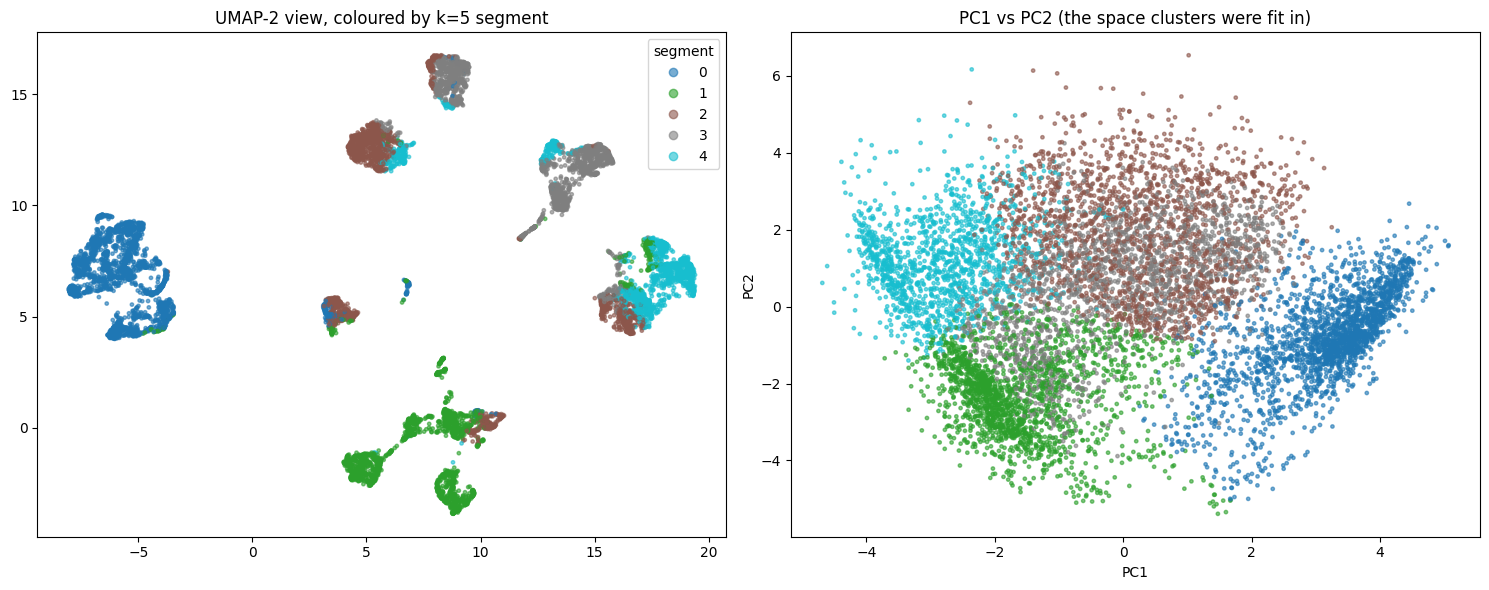

In [35]:
# CELL 34 — UMAP-2 map coloured by segment (presentation only)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sc = ax[0].scatter(X_umap2[:, 0], X_umap2[:, 1], c=prof["segment"], cmap="tab10", s=6, alpha=0.6)
ax[0].set_title("UMAP-2 view, coloured by k=5 segment"); ax[0].legend(*sc.legend_elements(), title="segment")
ax[1].scatter(X_pca[:, 0], X_pca[:, 1], c=prof["segment"], cmap="tab10", s=6, alpha=0.6)
ax[1].set_title("PC1 vs PC2 (the space clusters were fit in)"); ax[1].set_xlabel("PC1"); ax[1].set_ylabel("PC2")
plt.tight_layout(); plt.show()

## Closing summary

### The five segments and what to do with them

| # | Name | Share | Who they are (typical values) | Recommended action |
|---|---|---|---|---|
| 0 | **Cash-advance revolvers** | 24% | Do not use the card to buy (only 6% ever do). 99% take cash advances (median 1,259). Balance 1,497, running at 63% of limit, paying about 1.1× the minimum, never paying in full. | Debt-consolidation or personal-loan offer to replace expensive cash advances; credit-risk monitoring; interest-rate sensitivity. |
| 1 | **Light installment users** | 21% | Tiny balance (43), low limit (2,500), small installment purchases (315), 62% pay in full at some point. Most dormant accounts sit here. | Activation and engagement campaigns; savings-plan cross-sell; targeted limit increases to grow usage. |
| 2 | **Maxed-out heavy users** | 20% | Highest balance (2,532) and utilisation (71%), buy both ways (897), 67% also take cash advances, pay only ~1.1× the minimum. | Highest revenue and highest risk: balance-transfer / restructuring offers, hardship early-warning, no further limit increases. |
| 3 | **Occasional big-ticket buyers** | 20% | Buy infrequently (17% of months) but in large single purchases (average ticket 83, all one-off), moderate balance (818), no installments. | Convert big purchases to installment / BNPL plans; retail-partner and seasonal promotions. |
| 4 | **Transactors** | 16% | Highest spend (1,955), buy every month, highest limits (6,000), use only 8% of it, pay ~10× the minimum, 73% pay in full. | Premium card and rewards upgrade; wealth-management, investment and insurance cross-sell; retention. |

### Why this method, in one paragraph
The data had strong group structure (Hopkins 0.86) and, once every variable was put on a comparable scale, that structure turned out to be **linear**: a 7-dimension straight-line summary (PCA) preserved neighbourhoods essentially perfectly (trustworthiness 0.999), an independent estimate put the true dimensionality at about 5, and a simple linear rule reproduces the final segments with 99% accuracy. K-Means in that PCA space beat Gaussian mixtures, hierarchical clustering and HDBSCAN-on-UMAP on every fair measure. Five groups was chosen because it sits on the quality plateau, is the most stable under re-sampling (never below 0.78 agreement across 30 bootstrap refits), scores 6–7× better than the same pipeline on structure-free data, and gives five segments that are each 16–24% of customers and each nameable in plain language.

### Why the non-linear route (UMAP + HDBSCAN) was set aside
An earlier pass suggested UMAP and HDBSCAN because UMAP scored well on 2-D neighbourhood preservation and clusters inside a UMAP map had a high silhouette. Both readings were artefacts of comparing inside UMAP's own 2-D picture. Compared fairly — at realistic dimensions and scored in the original variable space — PCA matched or beat UMAP, and HDBSCAN either fragmented the customers into 11–17 tiny groups or, when constrained to five, scored below K-Means. The dramatic "islands" UMAP draws are the seven combinations of *which channels a customer uses at all* (one-off, installments, cash advance), which is useful to know but needs no non-linear method to find.

### Caveats
- Segments describe the last six months of behaviour; they should be re-scored periodically and the boundaries re-checked for drift.
- Silhouette values around 0.24 are typical for behavioural data: customers do not fall into perfectly separate boxes, and customers near a boundary are genuinely in-between.
- There is no outcome variable (profit, default, churn) in this dataset. The final validation step for a live deployment would be to confirm that the segments differ on such an outcome.
